In [7]:
pip install scikit-learn

     ---------------------------------------- 8.9/8.9 MB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 38.6/38.6 MB 1.9 MB/s eta 0:00:00
     -------------------------------------- 307.7/307.7 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
def get_feature_matrix_of_company_financial_statements():
    
    all_sheets = pd.read_excel('archivo.xlsx', sheet_name=None)



Epoch 50, Loss: 0.0000
Epoch 100, Loss: 0.0000
Epoch 150, Loss: 0.0000


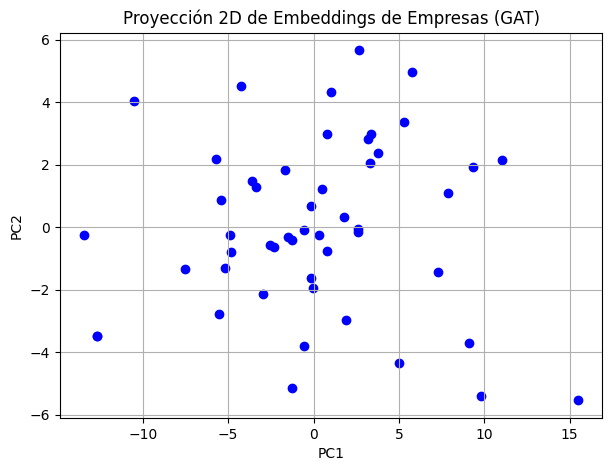

In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ======== 1. SIMULACIÓN DE DATOS ========
np.random.seed(42)
torch.manual_seed(42)

num_nodes = 50  # Simulamos 50 empresas
feature_dim = 16  # 16 características fundamentales y de precios

# Features nodales aleatorios (simulando métricas financieras)
node_features = torch.tensor(np.random.randn(num_nodes, feature_dim), dtype=torch.float)

# Creamos un grafo basado en similitud aleatoria (ejemplo: correlación > threshold)
correlation_matrix = np.corrcoef(node_features.numpy())
edges = []

for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if correlation_matrix[i, j] > 0.7:  # Umbral de similitud artificial
            edges.append([i, j])
            edges.append([j, i])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Grafo PyTorch Geometric
data = Data(x=node_features, edge_index=edge_index)

# ======== 2. MODELO GAT ========
class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=4)
        self.gat2 = GATConv(hidden_channels * 4, out_channels, heads=4, concat=False)

    def encode(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = self.gat2(x, edge_index)
        return x

    def decode(self, z, edge_pairs):
        src, dst = edge_pairs
        return (z[src] * z[dst]).sum(dim=1)

    def forward(self, x, edge_index, edge_pairs):
        z = self.encode(x, edge_index)
        pred = self.decode(z, edge_pairs)
        return torch.sigmoid(pred)

model = GATLinkPredictor(in_channels=feature_dim, hidden_channels=32, out_channels=16)

# ======== 3. PREPARAR ARISTAS PARA ENTRENAMIENTO (POSITIVAS Y NEGATIVAS) ========
# Positive edges (reales)
pos_edge_index = edge_index

# Negative edges (pares no conectados)
all_pairs = set((i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j)
existing_edges = set((int(i), int(j)) for i, j in edge_index.t().numpy())
negative_edges = list(all_pairs - existing_edges)
neg_samples = np.random.choice(len(negative_edges), len(pos_edge_index[0]) // 2, replace=False)
neg_edge_index = torch.tensor([negative_edges[i] for i in neg_samples], dtype=torch.long).t().contiguous()

# Training pairs and labels
train_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
train_labels = torch.cat([torch.ones(pos_edge_index.shape[1]), torch.zeros(neg_edge_index.shape[1])])

# ======== 4. ENTRENAMIENTO SIMPLE ========
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, train_edge_index)
    loss = F.binary_cross_entropy(out, train_labels)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ======== 5. OBTENER EMBEDDINGS Y VISUALIZAR ========
model.eval()
embeddings = model.encode(data.x, data.edge_index).detach().numpy()

# Reducimos a 2D para visualización
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue')
plt.title("Proyección 2D de Embeddings de Empresas (GAT)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()



In [13]:
np.random.randn(num_nodes, feature_dim)

array([[ 1.89706168e-01, -6.61982178e-01,  4.25887206e-01,
         1.91477774e-02, -6.41486909e-01,  4.87872285e-01,
         1.80434811e+00, -1.90903792e-01,  7.19757942e-01,
        -1.29327296e+00, -9.56436377e-01,  4.72406278e-01,
         1.48411603e+00,  3.55613349e-01, -3.13058031e-01,
        -7.08594577e-04],
       [-1.25040773e+00,  6.04515326e-01,  8.82333062e-01,
        -4.52090333e-01, -4.70042148e-01,  2.65878230e-01,
        -4.36719736e-01, -6.61326146e-02,  2.09972179e+00,
        -2.47025701e-01, -3.58340152e-01, -6.47541806e-01,
         7.44191971e-01, -1.81224173e-01, -6.49373038e-01,
         1.32130403e+00],
       [ 1.41960300e+00, -6.00423566e-01, -1.86653995e+00,
         1.00751369e+00, -6.84629826e-01,  7.90625599e-01,
        -1.97010382e+00,  8.92597338e-01, -1.21117193e+00,
         7.30764119e-01,  1.42730678e-02, -9.53939419e-01,
        -4.07036313e-01,  6.86318457e-01,  1.05894453e-01,
         5.84412980e-01],
       [ 1.97644058e+00, -1.56424161e

In [10]:
with torch.no_grad():
    z = model.encode(x, edge_index)
    scores = model.decode(z, nuevos_pares)


NameError: name 'x' is not defined